# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


 - Revise el archivo landing_experiment.csv que contiene registros de 40,000 usuarios, el dataset no contiene valores ausentes, los tipos de datos de cada columna son coreectos.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
print('Usuarios unicos:', df['user_id'].nunique())

Usuarios unicos: 40000


 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
print('Categorias por columna:')
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(col, ':', df[col].unique())


Categorias por columna:
landing : ['A' 'B']
region : ['Norte' 'Occidente' 'Centro' 'Sur' 'Oriente']
dispositivo : ['Mobile' 'Desktop']
traffic_source : ['Email' 'Organic' 'Ads' 'Referral']
user_type : ['Recurrente' 'Nuevo']


In [9]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1]
print (df['converted'].value_counts())

0    34294
1     5706
Name: converted, dtype: int64


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
print(df['landing'].value_counts())

B    20018
A    19982
Name: landing, dtype: int64


In [11]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in ['landing', 'region', 'dispositivo', 'traffic_source','user_type']:
        print(f'\nVariable:{col}')
print(df[col].value_counts())


Conteo de categorías:

Variable:landing

Variable:region

Variable:dispositivo

Variable:traffic_source

Variable:user_type
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


**Rango temporal:** El experimento se realiza del 01 de Enereo de 2026 al 29 de enero de 2026.

**Distribucion por version:** El experimento fue equitativo en  numero de usuarios entre la version A (19,982) y B (20,018). 

**Usuarios convertidos:** 5,706 usuarios convirtieron.

**Categorias:** No se detectaron errores ortograficos, valores duplicados, inusuales o categorias erroneas.


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
print('Cantidad de gastos convertidos en A:', len(gasto_A))
print('Cantidad de gastos convertidos en B:', len(gasto_B))
print(f'Gasto promedio en A: ${gasto_A.mean():2f}')
print(f'Gasto promedio en B: ${gasto_B.mean():2f}')

Cantidad de gastos convertidos en A: 2512
Cantidad de gastos convertidos en B: 3194
Gasto promedio en A: $61.086572
Gasto promedio en B: $68.745360


**-El gasto promedio en B representa un incremento del 12.54% respescto al gasto promedio en A.**

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe diferencia significativaen el gasto promedio por usuario convertido entre la pagina A y la pagina B.
- **Hipótesis alternativa (H₁):** Existe una diferencia significativa en el gasto promedio por usuario convertido entre la pagina A y la pagina B.

In [13]:
# Aplicar prueba
t_stat, p_value = stats.ttest_ind(gasto_A, gasto_B, equal_var=False)


# Visualizar resultados
print(f"Estadístico : {t_stat:.4f}")
print(f"Valor p: {p_value:.3e}")

alpha = 0.05   
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")


Estadístico : -9.4810
Valor p: 3.628e-21
Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipotesis nula < 0.05.

**Interpretación de negocio:**  
Los usuarios expuestos a la prueba B realizaron un gasto promedio de 68.75, mientras que los usuarios de la prueba A gastaron en promedio 61.09 en promedio. La diefrenecia de $7.66 por conversion a favor de la prueba B es estadisticamente significativa y confirma que la version B tiene un mayor valor de ticket promedio. 


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [14]:
# Número de usuarios convertidos por página
conversion_A= df[df['landing'] == 'A']['converted'].sum()
conversion_B= df[df['landing'] == 'B']['converted'].sum()

# Total de usuarios por página
total_A = (df['landing'] == 'A').sum()
total_B = (df['landing'] == 'B').sum()

tasa_A = conversion_A / total_A
tasa_B = conversion_B / total_B

print (f"Tasa de exitos pagina A: {tasa_A:2%}")
print (f"Tasa de exitos pagina B: {tasa_B:2%}")

print(f"Usuarios convertidos por página:\n A:{conversion_A / total_A:.2%} | B: {conversion_B/total_B:.2%}")
      
print(f"Total de usuarios por página: A:\n {total_A} | {total_B}")


Tasa de exitos pagina A: 12.571314%
Tasa de exitos pagina B: 15.955640%
Usuarios convertidos por página:
 A:12.57% | B: 15.96%
Total de usuarios por página: A:
 19982 | 20018


In [15]:
tabla_landing = pd.crosstab(df['landing'], df['converted'])

In [16]:
# Aplicar prueba
chi2_land, p_val_land, dof_land, expected_land = stats.chi2_contingency(tabla_landing)


# Visualizar resultados
print(f"Estadístico Chi2: {chi2_land:.4f}")
print(f"Valor p: {p_val_land:.4e}")

Estadístico Chi2: 93.3748
Valor p: 4.3272e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipotesis nula. 

**Interpretación de negocio:**  
La pagina B logro una tasa de conversion mayor al 15% (3,194 conversiones de 20,018 usuarios), superando sensiblemente a la pagina A, que registro 12.57% (2,512 conversiones de 19,982). El incremento de la version B representa una mejora de 3.39% puntos porcentuales en conversion.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La conversion es independientede la fuente de trafico.
- **Hipótesis alternativa (H₁):** La conversion depende de la fuente de trafico.

In [17]:
tabla_traffic = pd.crosstab(df['traffic_source'], df['converted'])
print (tabla_traffic)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [18]:
# Aplicar prueba
chi2_traf, p_value_traf, dof_traf, expected_traf = stats.chi2_contingency(tabla_traffic)

print(f'Estadistico CHi2: {chi2_traf: 4f}')
print(f'Valor p: {p_value_traf:4f}')


Estadistico CHi2:  8.662109
Valor p: 0.034138


In [19]:

tasa_trafico = df.groupby('traffic_source')['converted'].agg(
    total= 'count',
    convertidos= 'sum',
    tasa_conversion= 'mean'
)
print('\nResumen por canal de trafico:')
print(tasa_trafico)



Resumen por canal de trafico:
                total  convertidos  tasa_conversion
traffic_source                                     
Ads             11935         1759         0.147382
Email            6123          918         0.149927
Organic         17987         2480         0.137877
Referral         3955          549         0.138812


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipotesis nula al nivel de significancia del 5% (p= 0.0341 < 0.05).

**Interpretación de negocio:**  
Existen diferencias estadisticamente significativas entre los canales. Los canales con mayor eficiencia de conversion son Email(14.99%) y Ads(14.74%), superando a Referral (13.88%) y Organic(13.79%). No obstante, en termino de volumen total, Organic aporta la Mayor cantidad absoluta de conversiones (2,480) gracias al elevado trafico de usuarios 17,987.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La conversion es independiente del tipo de usuario (Nuevo vs Recurrente)
- **Hipótesis alternativa (H₁):** La conversion depende del tipo de usuario. 

In [20]:
tabla_user = pd.crosstab(df['user_type'], df['converted'])

In [21]:
# Aplicar prueba
chi2_user, p_value_user, dof_user, expected_user = stats.chi2_contingency(tabla_user)

print(f'Estadistico Chi2: {chi2_user:4f}')
print(f'Valor p: {p_value_user:4f}')

tasa_usuario = df.groupby('user_type')['converted'].agg(
    total= 'count',
    convertidos= 'sum',
    tasa_conversion= 'mean'
)
print('\nResumen por tipo de usuario:')
print(tasa_usuario)




Estadistico Chi2: 0.513485
Valor p: 0.473634

Resumen por tipo de usuario:
            total  convertidos  tasa_conversion
user_type                                      
Nuevo       26033         3738         0.143587
Recurrente  13967         1968         0.140904


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipotesis nula (p=0.4736 > 0.05).

**Interpretación de negocio:**  
La probabilidad de conversion de los usuarios nuevos (14.36%) y recurrentes (14.09%) no muestra una diferencia estadisticamente significativa. La version del diseño afecta a ambos perfiles de usuario por igual.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

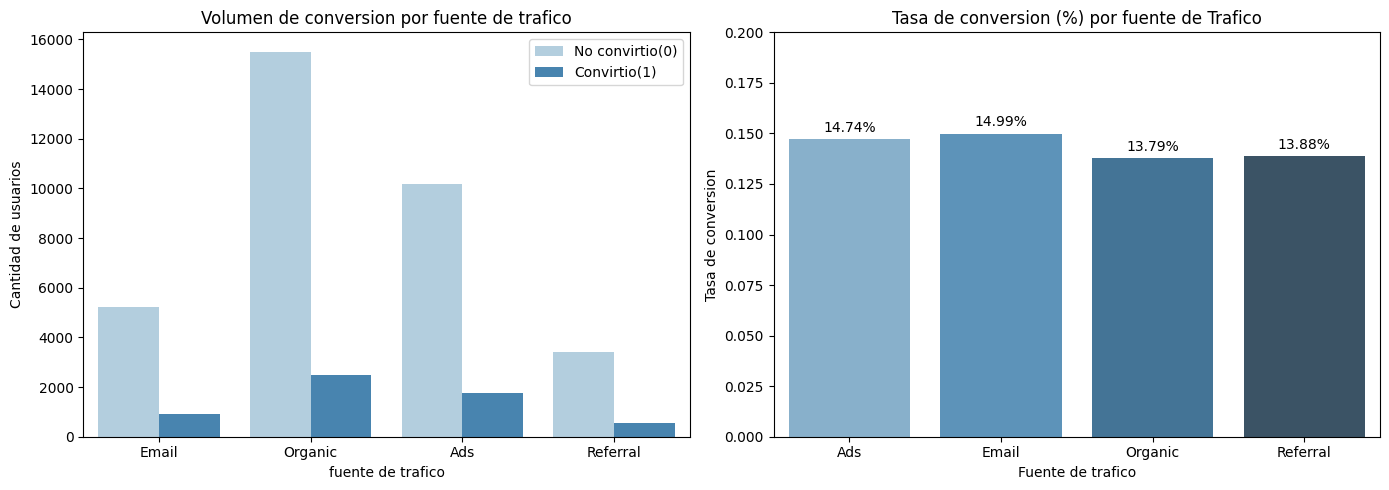

In [22]:

#Volumen absoluto por canal.
fig,axes=plt.subplots(1,2, figsize=(14,5))

sns.countplot(data=df, x='traffic_source', hue='converted', palette='Blues', ax=axes[0])
axes[0].set_title('Volumen de conversion por fuente de trafico')
axes[0].set_xlabel('fuente de trafico')
axes[0].set_ylabel('Cantidad de usuarios')
axes[0].legend(['No convirtio(0)', 'Convirtio(1)'])

#Tasa de conversion por canal
df_prop_traffic = df.groupby('traffic_source')['converted'].mean().reset_index()
sns.barplot(data=df_prop_traffic, x='traffic_source', y='converted', palette='Blues_d', ax=axes[1])
axes[1].set_title('Tasa de conversion (%) por fuente de Trafico')
axes[1].set_xlabel('Fuente de trafico')
axes[1].set_ylabel('Tasa de conversion')
axes[1].set_ylim(0, 0.20)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()


-En terminos de volumen absoluto, el canal Organic genera la mayor acntidad de clientes convertidos debido a su gran flujo de entradas.

-En terminos de eficiencia Email y Ads registran las tasas de conversion mas altas (14.99% y 14.74%), respectivamente)

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

### Relación entre el tipo de usuario y la conversión

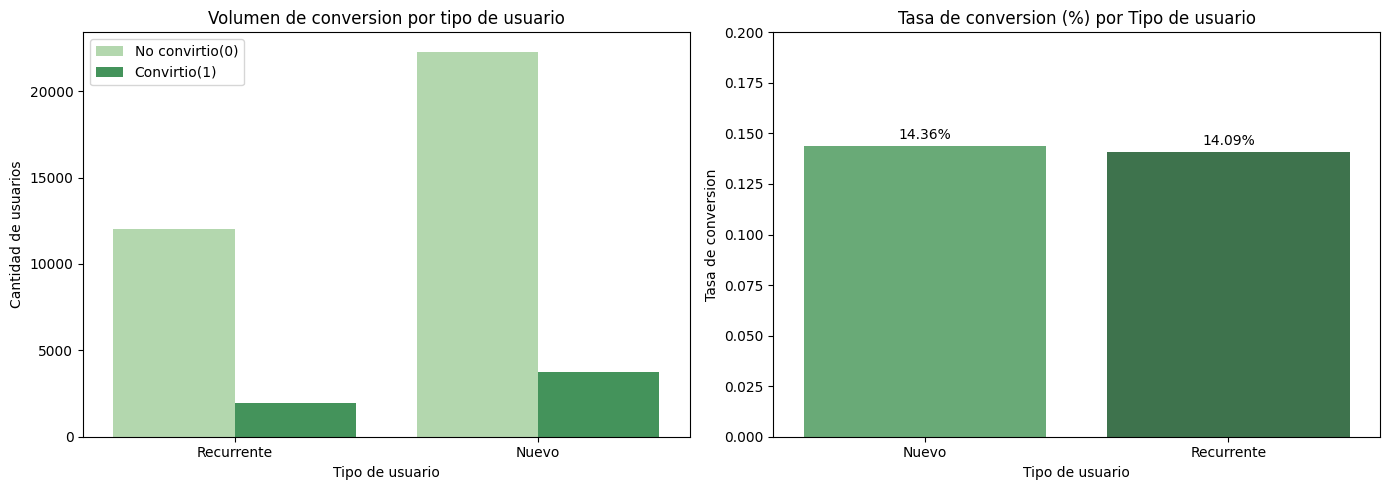

In [23]:
#Volumen absoluto por tipo de usuario.
fig,axes=plt.subplots(1,2, figsize=(14,5))

sns.countplot(data=df, x='user_type', hue='converted', palette='Greens', ax=axes[0])
axes[0].set_title('Volumen de conversion por tipo de usuario')
axes[0].set_xlabel('Tipo de usuario')
axes[0].set_ylabel('Cantidad de usuarios')
axes[0].legend(['No convirtio(0)', 'Convirtio(1)'])

#Tasa de conversion por canal
df_prop_user = df.groupby('user_type')['converted'].mean().reset_index()
sns.barplot(data=df_prop_user, x='user_type', y='converted', palette='Greens_d', ax=axes[1])
axes[1].set_title('Tasa de conversion (%) por Tipo de usuario')
axes[1].set_xlabel('Tipo de usuario')
axes[1].set_ylabel('Tasa de conversion')
axes[1].set_ylim(0, 0.20)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

-Los usurios Nuevos constituyen mas del 65% de la base total de visitantes y generan el mayor volumen absoluto de conversiones (3,738).

-La tasa porcentual de conversion se mantiene homogenea entre usuarios Nuevos (14.36%) y Recurrentes (14.09%), confirmando la falta de diferencia estadistica en este segmento.

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Observacion 1: La pagina B registra un gasto promedio por cliente convertido $68.75, frente a $61.09 de la pagina A.
- Observacion 2: La prueba t confirma esta diferencia +$7.66 por cliente es estadisticamente significativa.
- **Interpretación:**
- La conversion de la pagina B no solo logra enganchar a mas usuarios sino que genera carritos de compra de mayor valor.

<br>

**Tasa de conversión:** 
- Observacion 1 : La pagina B obtiene una tasa de conversion del 15.96%(3,194 conversiones), superando a la pagina A que obtiene 12.57%(2,512 conversiones).
- Observacion 2 : La prueba Chi2 arrojo un valor p de 4.33x10-22
- **Interpretación:**
-Implementar la version B incrementara la tasa total de conversion en 26.9% relativo.

#### 📊 **Segmentación por fuente de tráfico**
- Observacion: El canal Email 14.99% y los anuncios Ads 14.74% tienen las mayores tasas de conversion. El canal Organic reune el mayor volumen
  total de conversiones con 2,480.
- **Interpretación:**
- El trafico pagado y directo por correo electronico posee una intencion de compra superior, por lo que aumentar la inversion en estos canales
  maximizara el retorno.
 
 ---

#### 📊 **Segmentación por tipo de usuario**
- Observacion: La diferencia en conversion entre usuarios Nuevos (14.36%) y Recurrentes (14.09%) no es estadisticamente significativa.
- **Interpretación:**
- La experiencia en la pagina B beneficia por igual a los usuarios nuevos y habituales, por lo que es no es necesario crear alternativas
  en esta etapa.  
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Recomendación : Implementar la pagina B al 100% como version oficial, esto incrementara la tasa de conversion y el ticket de compra al mismo tiempo.
-  Recomendación: Reasignar presupuesto de marketing hacia Ads y Email: Dado que Ads y Email demostraron las tasas de conversion mas elevadas,
  se sugiere intensificar las campañas pagadas y las secuencias automatizadas por correo.